# Ejercicios: normalización en una CNN para CIFAR-10

En esta notebook compararemos el impacto de varias normalizaciones en el entrenamiento de una CNN básica para CIFAR-10.

La idea es mantener casi todo igual y cambiar solamente la normalización dentro del modelo:

- Sin normalización
- BatchNorm
- LayerNorm
- GroupNorm

Al final compararemos `loss` y `accuracy` de entrenamiento y validación en los mismos plots.


In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(7)
np.random.seed(7)

device = torch.device("cpu")
print(f"Dispositivo usado: {device}")


Dispositivo usado: cpu


## 2. Cargar CIFAR-10

Para evitar un entrenamiento largo, usaremos una parte pequeña del dataset.

**TODO 1:** cambia `train_subset_size`, `val_subset_size` o `batch_size` y observa si las métricas cambian mucho.


In [2]:
train_subset_size = 1000
val_subset_size = 500
batch_size = 100

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# int8 0 - 255 enteros
# Escalar: pasamos de int8 a float32 con valores entre 0 y 1
# Normalizar: se calcula el nuevo valor de pixeles basado en la media y desviación estándar
# z - score: (x - media) / desviación estándar
# valores de pixeles 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ..., 255

full_train_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

small_data = Subset(full_train_data, range(train_subset_size + val_subset_size))

generator = torch.Generator().manual_seed(7)
train_data, val_data = random_split(
    small_data,
    [train_subset_size, val_subset_size],
    generator=generator
)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

class_names = full_train_data.classes
print(f"Imágenes de entrenamiento: {len(train_data)}")
print(f"Imágenes de validación: {len(val_data)}")


Imágenes de entrenamiento: 1000
Imágenes de validación: 500


## 3. Ver algunas imágenes

Esto solo confirma que estamos trabajando con CIFAR-10.


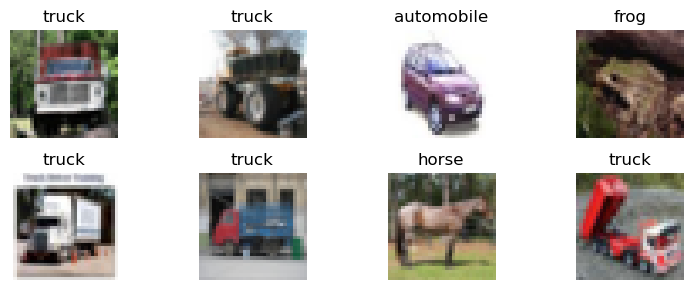

In [3]:
def show_images(loader, class_names):
    images, labels = next(iter(loader))
    means = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    stds = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    plt.figure(figsize=(8, 3))
    for index in range(8):
        image = images[index] * stds + means
        image = image.clamp(0, 1).permute(1, 2, 0)
        plt.subplot(2, 4, index + 1)
        plt.imshow(image)
        plt.title(class_names[labels[index]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_images(train_loader, class_names)


Observación **TODO 1**: Dado el conjunto de entrenamiento, validación y batch que se nos indica variar, noté que si acerco los valores de los tres conjuntos, las categorías visibles en las imágenes muestran imágenes repetidas. En cambio, si aumento el entrenamiento, mantengo la validación en aproximadamente la mitad del valor de entrenamiento y uso un batch aún menor, las imágenes tienden a ser mucho más variadas, aunque siguen identificándose correctamente.

## 4. Mismo modelo base, distinta normalización

La arquitectura será la misma en todos los experimentos. Solo cambiaremos la capa de normalización.

**TODO 2:** revisa la función `make_norm_layer`. Identifica qué dimensiones usa cada normalización.

**TODO 3:** agrega o quita una variante en `normalization_options` y vuelve a correr el entrenamiento.


In [4]:
def make_norm_layer(norm_name, num_channels):
    if norm_name == "none":
        return nn.Identity()
    if norm_name == "batch":
        return nn.BatchNorm2d(num_channels)
    if norm_name == "layer":
        return nn.GroupNorm(1, num_channels)
    if norm_name == "group":
        return nn.GroupNorm(4, num_channels)
    if norm_name == "instance":
        return nn.InstanceNorm2d(num_channels)
    raise ValueError(f"Normalización no válida: {norm_name}")

class BasicCNN(nn.Module):
    def __init__(self, norm_name):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            make_norm_layer(norm_name, 32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            make_norm_layer(norm_name, 64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            make_norm_layer(norm_name, 128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)

normalization_options = {
    "Sin normalización": "none",
    "BatchNorm": "batch",
    "LayerNorm": "layer",
    "GroupNorm": "group",
    "InstanceNorm": "instance" # Sacada de mis notas, no estaba en el código original
}

Observación **TODO 2**:
- **BatchNorm**: Usa la dimensión de los canales como parámetro.
- **LayerNorm**: Se usa como una forma práctica de LayerNorm sobre los canales y posiciones espaciales de cada muestra.
- **GroupNorm**: Los canales se dividen en 4 subconjuntos y cada uno se normaliza por separado.
- **InstanceNorm**: Normaliza cada muestra de forma independiente, sin usar grupos.

## 5. Funciones simples de entrenamiento y evaluación

No usaremos clases extra ni un pipeline complejo. Solo necesitamos medir `loss` y `accuracy`.


In [5]:
def train_one_epoch(model, loader, optimizer, loss_function):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def evaluate(model, loader, loss_function):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            total_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

## 6. Entrenar todas las variantes

Todas las variantes usan el mismo modelo base, el mismo optimizador, la misma tasa de aprendizaje y los mismos datos.

**TODO 4:** cambia `num_epochs` o `learning_rate`. Observa si alguna normalización se vuelve más estable o más inestable.


In [6]:
num_epochs = 5 # Valor de epocas que escoji para entrenar el modelo, ya que 10 epocas me parecia mucho
learning_rate = 0.001 # Valores probados: 0.0001, 0.001, 0.01 y 0.1

results = {}
loss_function = nn.CrossEntropyLoss()

for model_label, norm_name in normalization_options.items():
    torch.manual_seed(7)
    model = BasicCNN(norm_name).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    print(f"\nEntrenando modelo: {model_label}")
    for epoch in range(num_epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, loss_function)
        val_loss, val_accuracy = evaluate(model, val_loader, loss_function)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Época {epoch + 1:02d} | "
            f"loss train: {train_loss:.3f} | acc train: {train_accuracy:.3f} | "
            f"loss val: {val_loss:.3f} | acc val: {val_accuracy:.3f}"
        )

    results[model_label] = history


Entrenando modelo: Sin normalización
Época 01 | loss train: 2.284 | acc train: 0.135 | loss val: 2.220 | acc val: 0.206
Época 02 | loss train: 2.155 | acc train: 0.200 | loss val: 2.057 | acc val: 0.224
Época 03 | loss train: 2.053 | acc train: 0.217 | loss val: 2.084 | acc val: 0.200
Época 04 | loss train: 2.008 | acc train: 0.229 | loss val: 2.018 | acc val: 0.256
Época 05 | loss train: 1.949 | acc train: 0.271 | loss val: 1.949 | acc val: 0.270

Entrenando modelo: BatchNorm
Época 01 | loss train: 2.110 | acc train: 0.219 | loss val: 2.147 | acc val: 0.240
Época 02 | loss train: 1.894 | acc train: 0.329 | loss val: 2.024 | acc val: 0.250
Época 03 | loss train: 1.799 | acc train: 0.358 | loss val: 1.896 | acc val: 0.284
Época 04 | loss train: 1.712 | acc train: 0.407 | loss val: 1.821 | acc val: 0.324
Época 05 | loss train: 1.648 | acc train: 0.439 | loss val: 1.782 | acc val: 0.316

Entrenando modelo: LayerNorm
Época 01 | loss train: 2.255 | acc train: 0.161 | loss val: 2.184 | acc 

Observación **TODO 4**:
- Dejé el número de épocas en cinco, ya que las diez que había originalmente me parecían demasiadas para lo que queríamos probar, así que lo reduje. Para la tasa de entrenamiento utilicé cuatro valores: `0.0001`, `0.001`, `0.01` y `0.1` respectivamente, para observar si alguna normalización se volvía más estable o inestable. Noté que con los dos primeros valores, `0.0001` y `0.001`, el entrenamiento era lento y las normalizaciones se mantenían estables tanto en la pérdida como en la precisión, es decir, seguían un patrón lógico ascendente y descendente para la precisión y la pérdida respectivamente. En cuanto a los valores de `0.01` y `0.1`, el de `0.01`, comparado con los anteriores, también era estable aunque entrenaba más rápido; mientras que el último, 0.1, resultó ser inestable, sobre todo en la precisión, ya que comenzaba alta, luego disminuía y después volvía a aumentar hasta regresar al valor original.

## 7. Comparación final: loss train vs val

Cada normalización aparece con dos líneas: entrenamiento y validación.

**TODO 5:** identifica si alguna variante baja el `loss` de entrenamiento pero no mejora el `loss` de validación. Eso puede indicar sobreajuste o poca generalización.


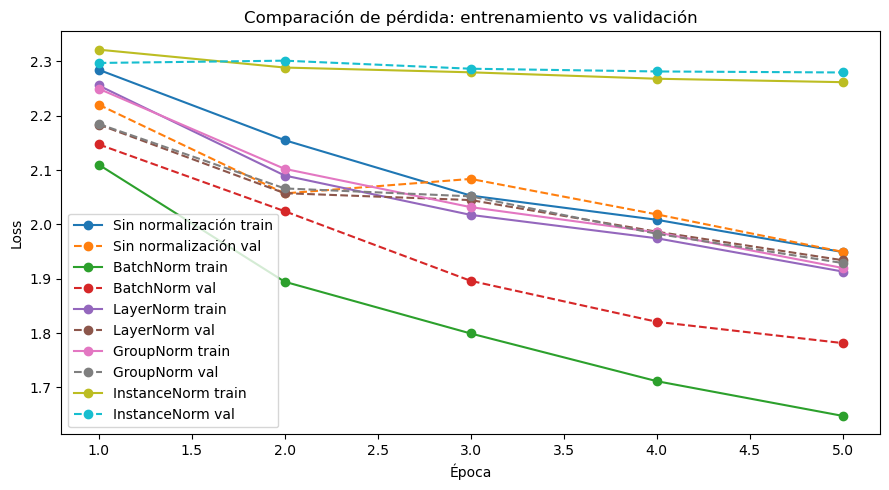

In [7]:
epochs = range(1, num_epochs + 1)

"""
Las partes de código comentadas que se encuentra debajo permite omitir la primera época en los gráficos 
de pérdida si el learning rate es muy alto (0.1), lo que puede causar que la pérdida inicial sea significativamente 
mayor que las pérdidas posteriores
"""

# Omitir la primera época si el learning rate es muy alto
skip_first = 1

plt.figure(figsize=(9, 5))
for model_label, history in results.items():
    plt.plot(epochs, history["train_loss"], marker="o", linestyle="-", label=f"{model_label} train")
    plt.plot(epochs, history["val_loss"], marker="o", linestyle="--", label=f"{model_label} val")

    # train_loss = history["train_loss"][skip_first:]
    # val_loss = history["val_loss"][skip_first:]
    # train_epochs = list(epochs)[skip_first:]

    # plt.plot(train_epochs, train_loss, marker="o", linestyle="-", label=f"{model_label} train")
    # plt.plot(train_epochs, val_loss, marker="o", linestyle="--", label=f"{model_label} val")

plt.title("Comparación de pérdida: entrenamiento vs validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

Observación **TODO 5**:

Analizando las comparaciones de pérdida entre entrenamiento y validación según mis tasas de entrenamiento, he notado como primer punto que la normalización estándar con **BatchNorm** resulta buena o estable, podría decirse, en todas las tasas de entrenamiento.

Observaciones sobre todas las normalizaciones, excepto **BatchNorm**, considerando las tasas de aprendizaje:
- Para `0.0001`: El "loss" de entrenamiento disminuía, pero el de validación no mejoraba y siempre se mantenía bajo.

- Para `0.001`: Este fue el mejor de todos, el más estable, con un error de entrenamiento por debajo del de validación.

- Para `0.01`: Igual que el primero, pero cabe destacar que en la tercera época las normalizaciones restantes se igualaban tanto en entrenamiento como en validación.

- Para `0.1`: En este caso, ni el entrenamiento ni la validación fluctuaban, sino que se mantenían iguales.

## 8. Comparación final: accuracy train vs val

Esta gráfica muestra si la mejora en entrenamiento también aparece en validación.

**TODO 6:** compara la separación entre las líneas de train y val. Una separación grande puede indicar que el modelo memoriza mejor el subconjunto de entrenamiento que el de validación.


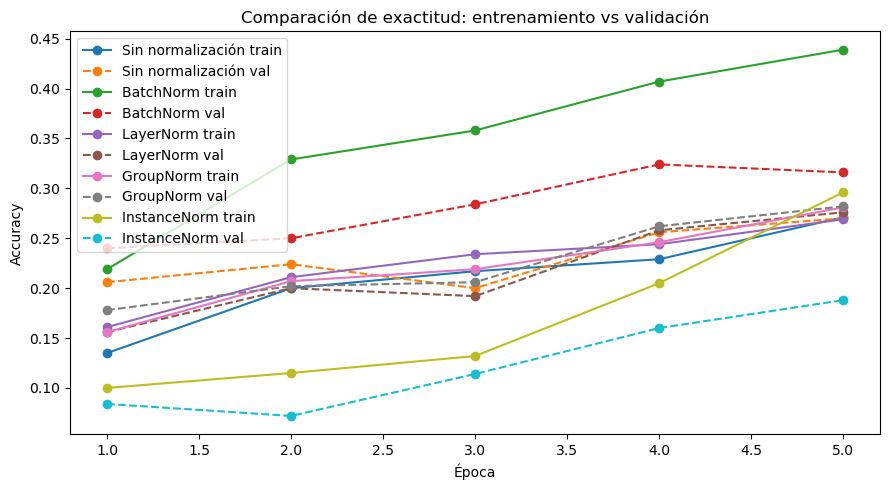

In [8]:
plt.figure(figsize=(9, 5))
for model_label, history in results.items():
    plt.plot(epochs, history["train_accuracy"], marker="o", linestyle="-", label=f"{model_label} train")
    plt.plot(epochs, history["val_accuracy"], marker="o", linestyle="--", label=f"{model_label} val")

plt.title("Comparación de exactitud: entrenamiento vs validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


Observación **TODO 6**:

Al analizar la separación entre las curvas de entrenamiento y validación según las distintas tasas de aprendizaje, observé lo siguiente: con `0.0001`, la normalización **BatchNorm** muestra una separación modesta, la mejor del gráfico, mientras que las demás apenas presentan diferencia; con **InsteadNorm**, la separación es casi nula, lo que indica que el modelo no memoriza más el conjunto de entrenamiento que el de validación. Con `0.001`, **BatchNorm** mantiene una separación moderada, pero las demás normalizaciones mejoran; con `0.01`, hay una ligera mejora respecto al caso anterior; y con `0.1`, **BatchNorm** presenta oscilaciones en sus lineas, mientras que las demás muestran una precisión baja con oscilaciones también.

## 9. Sensibilidad al tamaño de batch

BatchNorm usa estadísticas del minibatch. Por eso, con batches pequeños sus estimaciones pueden ser más ruidosas.

GroupNorm no usa estadísticas del batch. En este ejercicio lo comparamos contra BatchNorm usando el mismo modelo base y cambiando solo `batch_size`.

**TODO 7:** observa en qué tamaño de batch BatchNorm cambia más sus métricas.

**TODO 8:** compara si GroupNorm mantiene curvas más parecidas entre batch sizes.


Tamaño de batch: 4
  Entrenando BatchNorm
    Época 01 | loss val: 1.780 | acc val: 0.332
    Época 02 | loss val: 1.749 | acc val: 0.324
    Época 03 | loss val: 1.770 | acc val: 0.324
    Época 04 | loss val: 1.666 | acc val: 0.388
    Época 05 | loss val: 1.643 | acc val: 0.426
  Entrenando GroupNorm
    Época 01 | loss val: 2.074 | acc val: 0.214
    Época 02 | loss val: 1.985 | acc val: 0.222
    Época 03 | loss val: 1.901 | acc val: 0.256
    Época 04 | loss val: 1.831 | acc val: 0.336
    Época 05 | loss val: 1.814 | acc val: 0.300

Tamaño de batch: 8
  Entrenando BatchNorm
    Época 01 | loss val: 1.804 | acc val: 0.306
    Época 02 | loss val: 1.680 | acc val: 0.370
    Época 03 | loss val: 1.761 | acc val: 0.362
    Época 04 | loss val: 1.744 | acc val: 0.368
    Época 05 | loss val: 1.644 | acc val: 0.404
  Entrenando GroupNorm
    Época 01 | loss val: 2.066 | acc val: 0.216
    Época 02 | loss val: 1.953 | acc val: 0.240
    Época 03 | loss val: 1.945 | acc val: 0.294
    

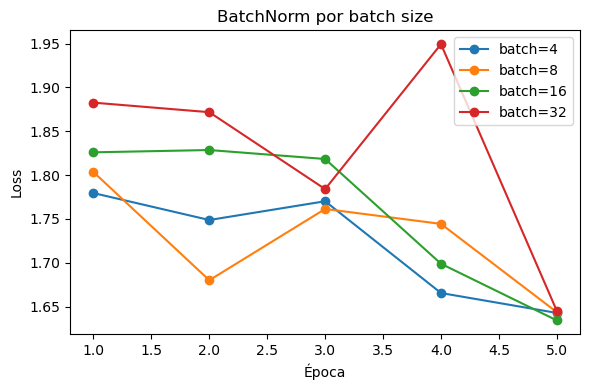

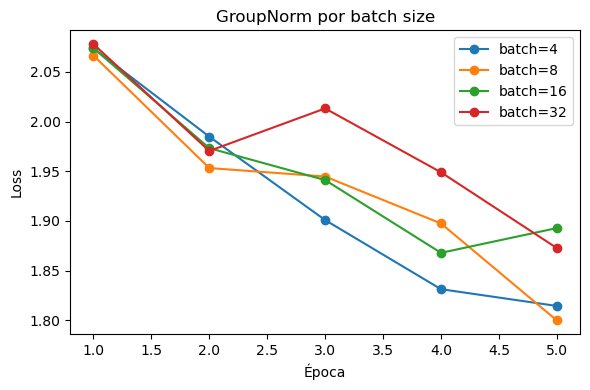

In [9]:
# Tamaños de batch utilizados para el experimento
# 1.- 9, 18, 36, 72
# 2.- 8, 16, 32, 64
# 3.- 4, 8, 16, 32

batch_sizes = [4, 8, 16, 32]
batch_experiment_epochs = 5
batch_norm_options = {
    "BatchNorm": "batch",
    "GroupNorm": "group"
}

batch_results = {}
batch_models = {}

for current_batch_size in batch_sizes:
    current_train_loader = DataLoader(train_data, batch_size=current_batch_size, shuffle=True)
    current_val_loader = DataLoader(val_data, batch_size=current_batch_size, shuffle=False)

    batch_results[current_batch_size] = {}
    batch_models[current_batch_size] = {}

    print(f"\nTamaño de batch: {current_batch_size}")

    for model_label, norm_name in batch_norm_options.items():
        torch.manual_seed(7)
        model = BasicCNN(norm_name).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        history = {
            "train_loss": [],
            "val_loss": [],
            "train_accuracy": [],
            "val_accuracy": []
        }

        print(f"  Entrenando {model_label}")
        for epoch in range(batch_experiment_epochs):
            train_loss, train_accuracy = train_one_epoch(
                model,
                current_train_loader,
                optimizer,
                loss_function
            )
            val_loss, val_accuracy = evaluate(model, current_val_loader, loss_function)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_accuracy"].append(train_accuracy)
            history["val_accuracy"].append(val_accuracy)

            print(
                f"    Época {epoch + 1:02d} | "
                f"loss val: {val_loss:.3f} | acc val: {val_accuracy:.3f}"
            )

        batch_results[current_batch_size][model_label] = history
        batch_models[current_batch_size][model_label] = model

# Graficar los resultados de pérdida por tamaño de batch y método de normalización

if "batch_results" in globals():
    methods = list(batch_norm_options.keys())  # "BatchNorm" y "GroupNorm"
    for method in methods:
        plt.figure(figsize=(6, 4))
        for b in batch_sizes:
            hist = batch_results[b][method]
            plt.plot(range(1, len(hist["val_loss"]) + 1), hist["val_loss"], marker="o", label=f"batch={b}")
        plt.title(f"{method} por batch size")
        plt.xlabel("Época")
        plt.ylabel("Loss")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No se encontró 'batch_results'")

Observación **TODO 7**:
- Analizando cada una de las tres gráficas de las diferentes métricas de "BatchNorm", he notado que todas son distintas entre sí. Sin embargo, en la gráfica con tamaños `[8, 16, 32, 64]`, específicamente en el "batch" de `32`, la pérdida aumenta de forma abrupta en la cuarta época, partiendo de un valor menor. De igual manera, en los tamaños `[4, 8, 16, 32]`, el "batch" de `32` presenta un aumento similar en la pérdida.

Observación: **TODO 8**:
- Al observar las tres gráficas que muestran las métricas de "GroupNorm", noté que, en general, las curvas se mantienen similares entre los distintos "batch sizes" cuando el lote es pequeño, y que la pérdida disminuye con cada tamaño de lote probado. Sin embargo, en este caso, los incrementos se presentan en la tercera época en cada una de las tres gráficas: primero con un lote de `36` y luego con uno de `32`.

## 10. Loss por tamaño de batch

Cada subplot corresponde a un tamaño de batch. Las líneas continuas son entrenamiento y las líneas punteadas son validación.

**TODO 9:** busca si algún método baja el `train_loss` pero no mejora el `val_loss`.

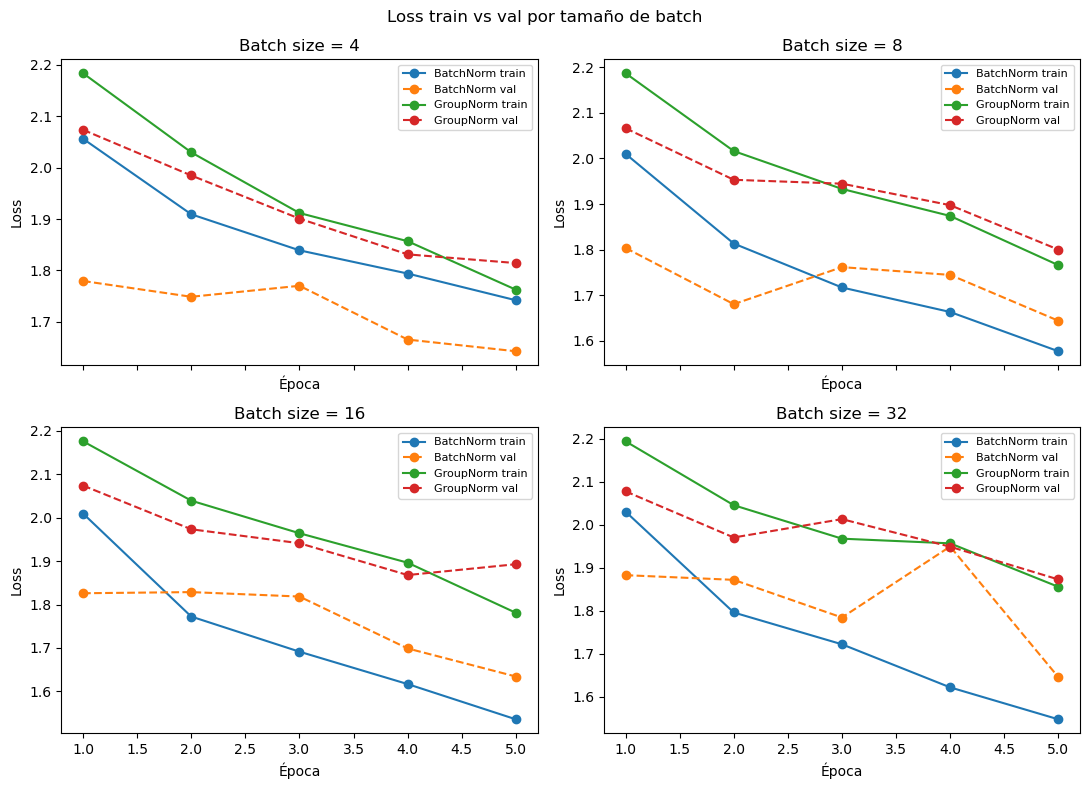

In [10]:
batch_epochs = range(1, batch_experiment_epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
axes = axes.reshape(-1)

for axis, current_batch_size in zip(axes, batch_sizes):
    for model_label, history in batch_results[current_batch_size].items():
        axis.plot(
            batch_epochs,
            history["train_loss"],
            marker="o",
            linestyle="-",
            label=f"{model_label} train"
        )
        axis.plot(
            batch_epochs,
            history["val_loss"],
            marker="o",
            linestyle="--",
            label=f"{model_label} val"
        )

    axis.set_title(f"Batch size = {current_batch_size}")
    axis.set_xlabel("Época")
    axis.set_ylabel("Loss")
    axis.legend(fontsize=8)

plt.suptitle("Loss train vs val por tamaño de batch")
plt.tight_layout()
plt.show()

Observación **TODO 9**:
- Observando los distintos **Batch sizes** presentes en la imagen, puedo decir que, en general, ninguno de los dos métodos mejora significativamente la pérdida de validación. El método que mostraría una mejoría sería el **BatchNorm**, ya que el recorrido del error de validación a lo largo de los **Batch sizes** no es tan errático ni distante como en el caso de **GroupNorm**. Sin embargo, este último tiene a su favor que sus pérdidas de validación son bajas en comparación con el método anterior, aunque desde el inicio no presenta una clara mejoría en la pérdida de validación al compararlo con el primero.

## 11. Accuracy por tamaño de batch

Esta figura muestra si los cambios de batch size afectan de forma parecida a entrenamiento y validación.

**TODO 10:** identifica si BatchNorm o GroupNorm tiene una validación más estable al cambiar el tamaño de batch.

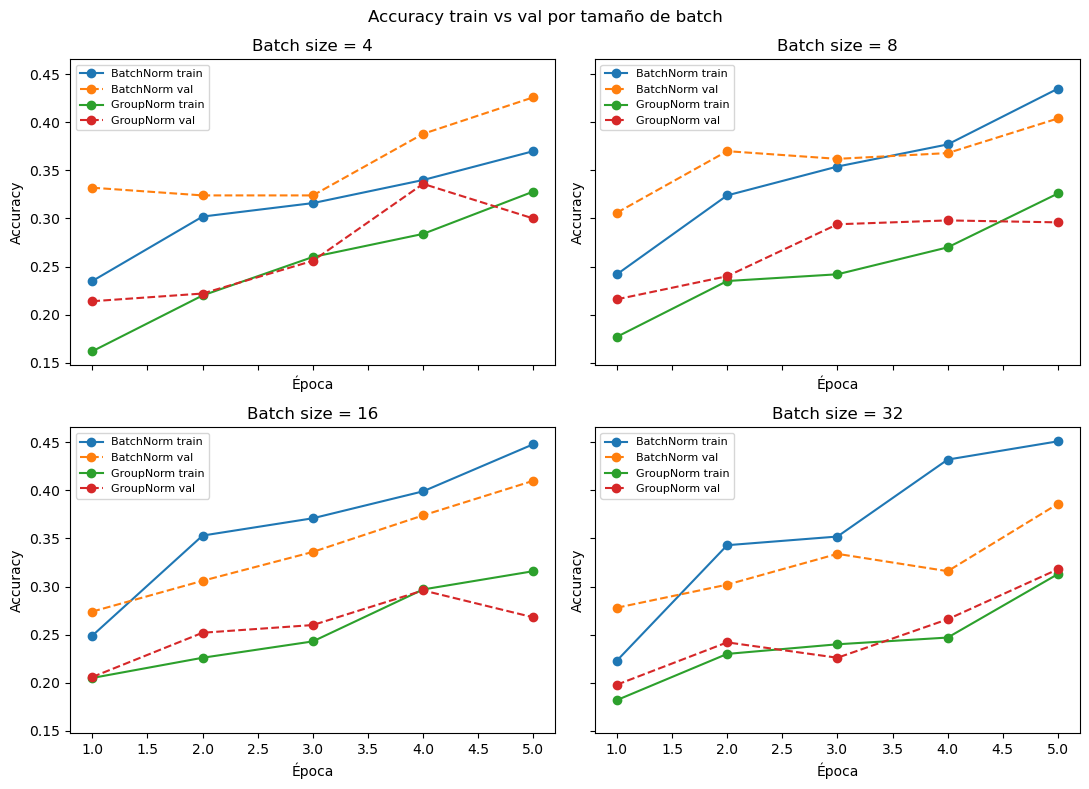

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for axis, current_batch_size in zip(axes, batch_sizes):
    for model_label, history in batch_results[current_batch_size].items():
        axis.plot(
            batch_epochs,
            history["train_accuracy"],
            marker="o",
            linestyle="-",
            label=f"{model_label} train"
        )
        axis.plot(
            batch_epochs,
            history["val_accuracy"],
            marker="o",
            linestyle="--",
            label=f"{model_label} val" 
        )

    axis.set_title(f"Batch size = {current_batch_size}")
    axis.set_xlabel("Época")
    axis.set_ylabel("Accuracy")
    axis.legend(fontsize=8)

plt.suptitle("Accuracy train vs val por tamaño de batch")
plt.tight_layout()
plt.show()

Observacion **TODO 10**:

- Observando y analizando cada tamaño de **Batch size**, específicamente cada **batch** individual atraves de cada **Batch size** note que **GroupNorm** tiende a ser más estable que **BatchNorm** dados mis **Batch size** propuestos. He de notar que en los dos métodos las variaciones en las validaciones no eran tan bruscas si no un aumento en la precision era lo que las volvía inestables.

## 12. Histogramas de activaciones

Ahora miramos una distribución interna del modelo. Usaremos las activaciones después del primer bloque convolucional.

Esto no reemplaza las métricas, pero ayuda a ver si las normalizaciones producen escalas internas distintas.

**TODO 11:** relaciona estos histogramas con las curvas de `loss` y `accuracy`.

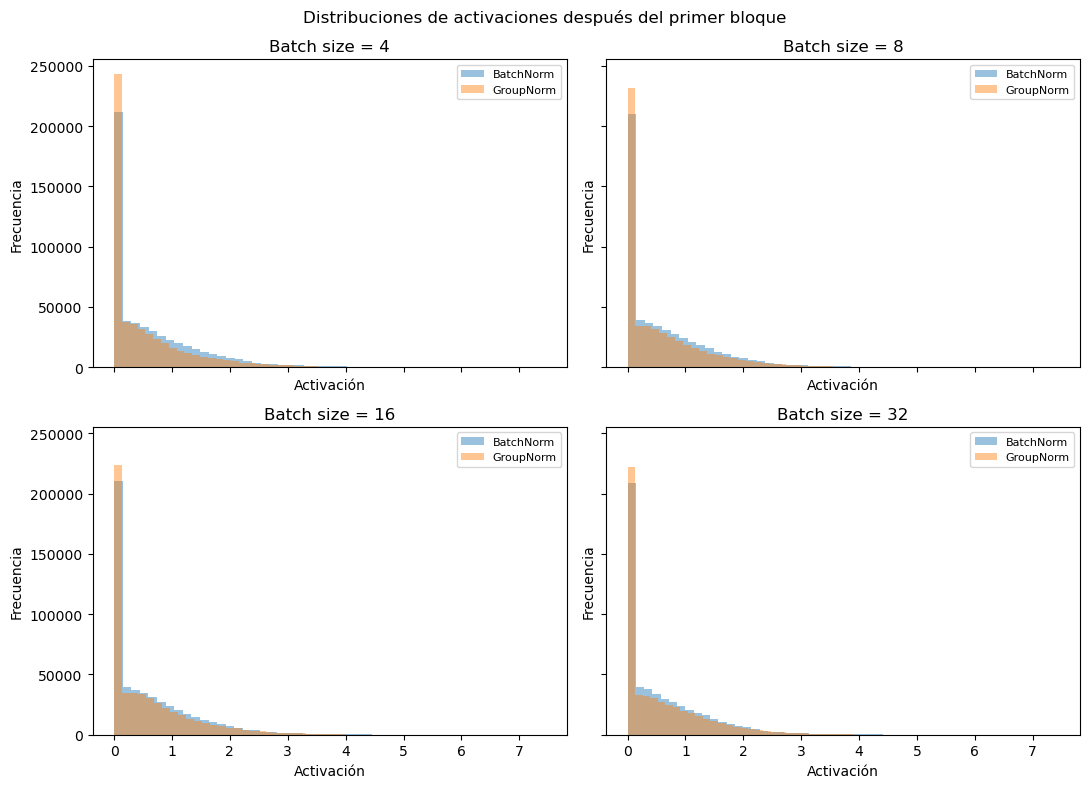

In [12]:
def get_first_block_activations(model, images):
    model.eval()
    with torch.no_grad():
        x = images.to(device)
        for layer in model.features[:4]:
            x = layer(x)
    return x.detach().cpu().reshape(-1).numpy()


validation_images, _ = next(iter(DataLoader(val_data, batch_size=64, shuffle=False)))

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.reshape(-1)

for axis, current_batch_size in zip(axes, batch_sizes):
    for model_label in batch_norm_options.keys():
        activations = get_first_block_activations(
            batch_models[current_batch_size][model_label],
            validation_images
        )
        axis.hist(activations, bins=50, alpha=0.45, label=model_label)

    axis.set_title(f"Batch size = {current_batch_size}")
    axis.set_xlabel("Activación")
    axis.set_ylabel("Frecuencia")
    axis.legend(fontsize=8)

plt.suptitle("Distribuciones de activaciones después del primer bloque")
plt.tight_layout()
plt.show()

Observacion **TODO 11**:
- Los histogramas me muestran que **GroupNorm** genera activaciones más homogéneas entre batch sizes, mientras que **BatchNorm** cambia más su distribución con batches pequeños. Esa mayor consistencia de **GroupNorm** empata con curvas de val_loss y val_accuracy más parecidas entre los distintos batch_size. Por eso, en mis batch sizes, los histogramas confirman la idea de que **GroupNorm** es menos sensible al tamaño de batch y produce entrenamiento más estable.

## 13. Preguntas de análisis

Responde después de ejecutar la notebook:

1. ¿Qué modelo obtiene menor `val_loss` en el experimento principal?
- `BatchNorm` obtiene el menor `val_loss` con (1.782). `GroupNorm` queda segundo con (1.929).
2. ¿Qué modelo obtiene mayor `val_accuracy` en el experimento principal?
- `BatchNorm` tiene la mayor `val_accuracy` final con (0.316).
3. ¿Algún modelo mejora mucho en entrenamiento pero poco en validación?
- `BatchNorm` muestra la mayor brecha entre `train_accuracy` con (0.439) y `val_accuracy` con (0.316), lo que indica que mejora más en entrenamiento que en validación.
4. ¿GroupNorm o LayerNorm se comportan de forma más estable en el experimento principal?
- En mis experimentos, `GroupNorm` y `LayerNorm` quedan bastante parejos, con `GroupNorm` ligeramente mejor en `val_loss` y `val_acc`.
5. ¿BatchNorm parece más sensible que GroupNorm al tamaño de batch?
- Sí. `GroupNorm` tiende a ser más estable para los `batch_sizes` propuestos, mientras que `BatchNorm` muestra más variación cuando cambia el tamaño del batch. Eso empata con la idea general: `BatchNorm` depende de estadísticas del minibatch, y por eso es más sensible a `batch_size`.
6. ¿Los histogramas de activaciones ayudan a explicar alguna diferencia en las métricas?
- Sí. Ya que:
   - `GroupNorm` produce activaciones más homogéneas entre los distintos batch sizes.
   - `BatchNorm` cambia más su distribución con batches pequeños.

   Esa diferencia en los histogramas explica por qué las curvas de `val_loss` y `val_accuracy` de `GroupNorm` son más parecidas entre batch sizes: las activaciones internas son más constantes, lo que da entrenamiento más estable.

Conclusión importante: este experimento es ilustrativo. No demuestra que una normalización sea siempre mejor. El resultado depende del modelo, los datos, el tamaño del batch, la tasa de aprendizaje y el número de épocas.
